In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import sympy as sp 
import cvxpy as cp

# Mean-variance optimization: Totally simple

In [2]:
# Make lambda an array with 8 values between 0 and 1
n=8 #Number of assets
lambdas = np.linspace(0, 1, 8)
A=np.random.uniform(-1, 1, (n, n)) #Randomly generated covariance matrix
Q=A.T @ A #Covariance matrix
Q = Q / Q.max() #Normalize covariance matrix
np.fill_diagonal(Q, 1)
returns=np.random.rand(n) #Randomly generated returns for each asset
#Define mean-variance frontier
def f(lambdas, x, Q, returns):
    sigma=cp.quad_form(x, Q)
    ret=returns @ x
    return lambdas * sigma - (1 - lambdas) * ret
#Define optimization problem without constraints with cvxpy with function f as objective
def optimize_portfolio(lamb, Q, returns):
    x = cp.Variable(n)
    objective = cp.Minimize(f(lamb, x, Q, returns))
    constraints=[cp.sum(x) == 1, x >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return x.value
for lamb in lambdas:
    weights = optimize_portfolio(lamb, Q, returns)
    weights=np.maximum(weights, 0) #Set negative weights to 0
    weights=weights / np.sum(weights) #Normalize weights to sum to 1
    print(f"Lambda: {lamb}, Weights: {weights}")






Lambda: 0.0, Weights: [8.23989867e-30 1.00000000e+00 8.30923215e-30 7.93637211e-30
 7.94792769e-30 8.33619517e-30 1.38777957e-23 8.32618034e-30]
Lambda: 0.14285714285714285, Weights: [0.         0.60155544 0.         0.00696466 0.04770031 0.
 0.34377959 0.        ]
Lambda: 0.2857142857142857, Weights: [3.93596268e-23 2.40451307e-01 1.24557810e-22 1.53494349e-01
 2.83094854e-01 0.00000000e+00 3.22959489e-01 6.42659631e-23]
Lambda: 0.42857142857142855, Weights: [3.97349255e-23 1.25295004e-01 0.00000000e+00 1.84709871e-01
 3.11858690e-01 7.96290213e-02 2.98507414e-01 0.00000000e+00]
Lambda: 0.5714285714285714, Weights: [4.96961388e-24 6.98709139e-02 0.00000000e+00 1.93031933e-01
 3.05698713e-01 1.52354955e-01 2.79043485e-01 0.00000000e+00]
Lambda: 0.7142857142857142, Weights: [0.04023058 0.01623226 0.03151006 0.17547375 0.26435074 0.17138076
 0.26609951 0.03472234]
Lambda: 0.8571428571428571, Weights: [0.06866824 0.         0.07790932 0.14734251 0.20874288 0.18244198
 0.25546808 0.0594269

# Constraint number one Zi

In [3]:
#I add a binary value Zi. If Zi=1 it is in the portfolio if Zi=0 its not. The constraint is the sum of Zi must be greater than or equal to 5
#Define optimization problem with binary variables
def optimize_portfolio_with_binary(lamb, Q, returns):
    x = cp.Variable(n)
    Z = cp.Variable(n, boolean=True)
    objective = cp.Minimize(f(lamb, x, Q, returns))
    constraints=[cp.sum(x) == 1, x >= 0, x <= Z, cp.sum(Z) >= 5, x >= 0.01 * Z]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.GUROBI) 
    return x.value, Z.value
for lamb in lambdas:
    weights, z_values=optimize_portfolio_with_binary(lamb, Q, returns)
    z_values = np.round(z_values).astype(int)
    weights=np.maximum(weights, 0) #Set negative weights to 0
    weights=weights / np.sum(weights) #Normalize weights to sum to 1
    print(f"Lambda: {lamb}, Weights: {weights}")
    print(f"Lambda: {lamb}, Binary Values: {z_values}")


Restricted license - for non-production use only - expires 2027-11-29
Lambda: 0.0, Weights: [0.01 0.96 0.   0.01 0.01 0.   0.01 0.  ]
Lambda: 0.0, Binary Values: [1 1 0 1 1 0 1 0]
Lambda: 0.14285714285714285, Weights: [0.         0.60095811 0.         0.01       0.04101671 0.01
 0.33802519 0.        ]
Lambda: 0.14285714285714285, Binary Values: [0 1 0 1 1 1 1 0]
Lambda: 0.2857142857142857, Weights: [0.         0.24110581 0.         0.15128062 0.27685328 0.01
 0.32076029 0.        ]
Lambda: 0.2857142857142857, Binary Values: [0 1 0 1 1 1 1 0]
Lambda: 0.42857142857142855, Weights: [0.         0.125295   0.         0.18470987 0.31185869 0.07962902
 0.29850741 0.        ]
Lambda: 0.42857142857142855, Binary Values: [0 1 0 1 1 1 1 0]
Lambda: 0.5714285714285714, Weights: [0.         0.06987091 0.         0.19303193 0.30569871 0.15235496
 0.27904348 0.        ]
Lambda: 0.5714285714285714, Binary Values: [0 1 0 1 1 1 1 0]
Lambda: 0.7142857142857142, Weights: [0.04023058 0.01623226 0.03151006 0

# Mean - variance transaction cost

In [ ]:
# Make a mean varaince function with transaction cost. The flat fee and linear fee
c0 = 0.001   # flat fee estimate
c1 = 0.005  # position linear cost
x_bar = 0.10 #Price goes from flat fee to linear fee
def f_transaction(lamb, x0, x1, z_bin, Q, returns, c0, c1):
    x = x0 + x1
    sigma = cp.quad_form(x, Q)
    # Return on total holdings minus transaction costs
    ret = returns @ x - c0*cp.sum(z_bin) - c1*cp.sum(x1)
    return lamb * sigma - (1 - lamb) * ret

In [5]:
def optimize_portfolio_with_transaction_cost(lamb, Q, returns, c0, c1):
    x0=cp.Variable(n) #Weights at flat fee
    x1=cp.Variable(n) #Weights at linear fee
    z_bin=cp.Variable(n, boolean=True) #Binary variable for flat fee
    objective = cp.Minimize(f_transaction(lamb, x0, x1, z_bin, Q, returns, c0, c1))
    constraints=[cp.sum(x0+x1)==1, x0>=0, x0<=x_bar*z_bin, x1>=0, x1<=z_bin, cp.sum(z_bin)>=5, x0+x1>=0.01*z_bin]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.GUROBI)
    return x0.value, x1.value, z_bin.value


# Mean variance revision

In [54]:
x_low_sell = 0.001
x_high_sell = 0.99
x_low_buy = 0.001   
x_high_buy = 0.99

In [39]:
n=len(mu)
def revise_portfolio(lamb,Q,returns,exist, n):
    print(f"n={n}")
    print(f"exist shape={exist.shape}")
    print(f"Q shape={Q.shape}")
    print(f"returns shape={returns.shape}")
    zplus=cp.Variable(n, boolean=True)
    zminus=cp.Variable(n, boolean=True)
    z_final = cp.Variable(n, boolean=True)
    x0=exist
    yplus=cp.Variable(n)
    yminus=cp.Variable(n)
    x=x0+yplus-yminus
    objective=cp.Minimize(f(lamb, x, Q, returns))
    constraints = [cp.sum(x)==1, yplus>=0, yplus<=zplus, yminus>=0, yminus<=zminus, 
                   x0+yplus>=x_low_buy*zplus, x0+yplus<=x_high_buy*zplus+(1-zplus),
                   x0-yminus>=x_low_sell*zminus, x0-yminus<=x_high_sell*zminus+(1-zminus),
                   zplus + zminus <= 1, x >= 0, x>=0.01*z_final, cp.sum(z_final)>=5]
    prob=cp.Problem(objective, constraints)
    prob.solve(solver=cp.GUROBI)
    return (x0 + yplus.value - yminus.value), zplus.value, zminus.value


# Benchmark testing with Yassine Hallal (Master graduate)

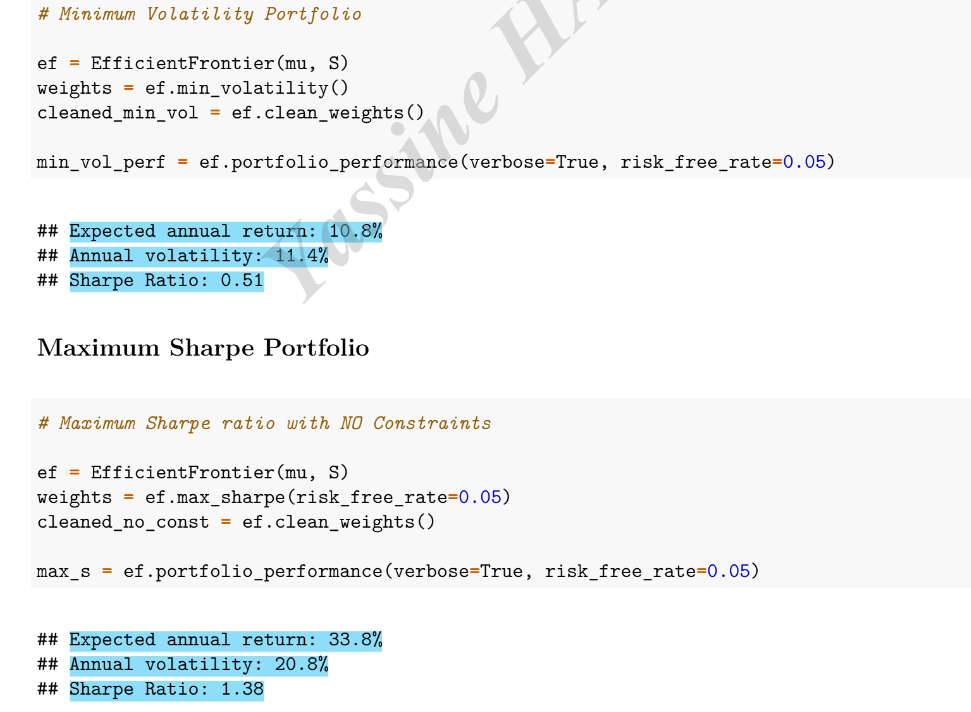

In [8]:
import yfinance as yf
tickers = ['AAPL', 'JNJ', 'PG', 'JPM', 'XOM', 'AMZN', 'KO', 'MSFT', 'GOLD', 'CVX']
data = yf.download(tickers, start="2015-01-01", end="2020-01-01")['Close']


[*********************100%***********************]  10 of 10 completed


In [32]:
prices=data
prices.reset_index(inplace=True)
prices.set_index('Date', inplace=True)
returns=np.log(prices/prices.shift(1)).dropna()
Q2 = returns.cov().values * 252

from pypfopt import expected_returns
mu = expected_returns.mean_historical_return(
    prices,
    compounding=True,
    frequency=252
).values


In [33]:
lambdas = np.linspace(0,1,500)
n=len(mu)
for lamb in lambdas:
    weights=optimize_portfolio(lamb, Q2, mu)
    weights=np.maximum(weights, 0) #Set negative weights to 0
    weights=weights / np.sum(weights) #Normalize weights to sum to 1
    portfolio_return = mu @ weights
    portfolio_volatility = np.sqrt(weights @ Q2 @ weights)
    sharpe_ratio=(portfolio_return-0.05)/portfolio_volatility
    print(f"Lambda: {lamb:.2f}, Return: {portfolio_return:.1%}, Volatility: {portfolio_volatility:.1%}, Sharpe Ratio: {sharpe_ratio:.2f}")

Lambda: 0.00, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.00, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.00, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.01, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.01, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.01, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.01, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.01, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.02, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.02, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.02, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.02, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.02, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.03, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 1.32
Lambda: 0.03, Return: 43.2%, Volatility: 29.0%, Sharpe Ratio: 

In [ ]:
best_sharpe = -np.inf
for lamb in lambdas:
    weights = optimize_portfolio(lamb, Q2, mu)

    port_return = mu @ weights
    port_vol = np.sqrt(weights @ Q2 @ weights)
    sharpe = (port_return - 0.05) / port_vol

    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_weights = weights
print(f"Best Sharpe Ratio: {best_sharpe:.2f}, Weights: {best_weights}")
print(f"Expected Return: {mu @ best_weights:.1%}, Volatility: {np.sqrt(best_weights @ Q2 @ best_weights):.1%}")
print(f"Best Sharpe Ratio: {best_sharpe:.2f}")

Best Sharpe Ratio: 1.37, Weights: [5.02708481e-23 5.91189651e-01 5.50757005e-23 8.32199736e-24
 6.88024960e-23 1.55640419e-01 5.11800746e-23 2.53169930e-01
 1.02140151e-22 4.99298060e-23]
Expected Return: 36.4%, Volatility: 22.9%
Best Sharpe Ratio: 1.37


In [27]:
best_vol = np.inf

for lamb in lambdas:
    weights = optimize_portfolio(lamb, Q2, mu)

    weights = np.maximum(weights, 0)
    weights = weights / np.sum(weights)

    portfolio_return = mu @ weights
    portfolio_variance = weights @ Q2 @ weights
    portfolio_volatility = np.sqrt(portfolio_variance)

    if portfolio_volatility < best_vol:
        best_vol = portfolio_volatility
        best_weights = weights
        best_return = portfolio_return

print("Best weights:", best_weights)
print(f"Return: {best_return:.1%}")
print(f"Volatility: {best_vol:.1%}")
print(f"Sharpe Ratio: {(best_return - 0.05) / best_vol:.2f}")

Best weights: [2.79502813e-02 1.20270933e-02 8.62844785e-24 9.28495204e-02
 1.94267792e-01 6.29713476e-02 3.44539254e-01 1.33957475e-23
 1.68036178e-01 9.73585341e-02]
Return: 8.8%
Volatility: 11.2%
Sharpe Ratio: 0.34


In [14]:
from scipy.optimize import minimize
rf = 0.05

def neg_sharpe(weights, mu, Q, rf):
    port_return = mu @ weights
    port_vol = np.sqrt(weights @ Q @ weights)
    return -(port_return - rf) / port_vol

def optimize_sharpe(mu, Q, rf=0.05):
    n = len(mu)
    x0 = np.ones(n) / n

    bounds = [(0, 1) for _ in range(n)]
    constraints = {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }

    result = minimize(
        neg_sharpe,
        x0,
        args=(mu, Q, rf),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return result.x

weights = optimize_sharpe(mu, Q2, rf=0.05)

portfolio_return = mu @ weights
portfolio_volatility = np.sqrt(weights @ Q2 @ weights)
sharpe_ratio = (portfolio_return - 0.05) / portfolio_volatility

print("Weights:", weights)
print(f"Return: {portfolio_return:.1%}")
print(f"Volatility: {portfolio_volatility:.1%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Weights: [1.73316026e-16 5.27397133e-01 1.41535971e-17 0.00000000e+00
 0.00000000e+00 1.90112487e-01 0.00000000e+00 2.82490380e-01
 0.00000000e+00 1.76513227e-16]
Return: 30.0%
Volatility: 22.1%
Sharpe Ratio: 1.13


# Binary model

In [34]:
n=len(mu)
for lamb in lambdas:
    weights, z_values = optimize_portfolio_with_binary(lamb, Q2, mu)
    weights = np.maximum(weights, 0)
    weights = weights / np.sum(weights)
    portfolio_return = mu @ weights
    portfolio_volatility = np.sqrt(weights @ Q2 @ weights)
    sharpe = (portfolio_return - 0.05) / portfolio_volatility
    print(f"λ={lamb:.2f}: Return={portfolio_return:.1%}, Vol={portfolio_volatility:.1%}, Sharpe={sharpe:.2f}")


λ=0.00: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.00: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.00: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.01: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.01: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.01: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.01: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.01: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.02: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.02: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.02: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.02: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.02: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.03: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.03: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.03: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.03: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.03: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.04: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.04: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.04: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.04: Return=42.3%, Vol=28.2%, Sharpe=1.32
λ=0.04: Re

#### It checks out with benchmark

# Comparison of transaction with binary

In [35]:
for lamb in lambdas:
    x0, x1, z_values = optimize_portfolio_with_transaction_cost(lamb, Q2, mu, c0, c1)
    z_values = np.round(z_values).astype(int)
    weights = x0 + x1
    weights = np.maximum(weights, 0)
    
    gross_return = mu @ weights
    transaction_costs = c0 * z_values.sum() + c1 * np.sum(x1)
    net_return = gross_return - transaction_costs
    portfolio_volatility = np.sqrt(weights @ Q2 @ weights)
    sharpe = (net_return - 0.05) / portfolio_volatility
    
    print(f"λ={lamb:.2f}: Gross={gross_return:.1%}, Costs={transaction_costs:.3%}, Net={net_return:.1%}, Vol={portfolio_volatility:.1%}, Sharpe={sharpe:.2f}")


λ=0.00: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.00: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.00: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.01: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.01: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.01: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.01: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.01: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.02: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.02: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.02: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.02: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.02: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.03: Gross=42.3%, Costs=0.930%, Net=41.4%, Vol=28.2%, Sharpe=1.29
λ=0.03: Gross=42.3%, Costs=0.930%,

### It checks out with benchmark

# Portfolio revision benchmark

In [36]:
lamb = 0.71
stage1_weights, z=optimize_portfolio_with_binary(lamb,Q2, mu)
print(f"Stage 1 Weights: {stage1_weights}")

Stage 1 Weights: [0.01       0.69390967 0.         0.         0.         0.05351811
 0.         0.23257222 0.01       0.        ]


In [37]:
exist=np.array(stage1_weights)

In [40]:
n=len(mu)
revised_weights, zplus, zminus=revise_portfolio(lamb, Q2, mu, exist, len(mu))
print(f"Revised Weights: {revised_weights}")

n=10
exist shape=(10,)
Q shape=(10, 10)
returns shape=(10,)
Revised Weights: [0.01       0.69390967 0.         0.         0.         0.05351811
 0.         0.23257222 0.01       0.        ]


In [43]:
exist2 = np.array([0.1]*10)
revised_weights2, zplus2, zminus2=revise_portfolio(lamb, Q2, mu, exist2, len(mu))
print(f"Revised Weights: {revised_weights2}")

n=10
exist shape=(10,)
Q shape=(10, 10)
returns shape=(10,)
Revised Weights: [0.01       0.69343639 0.001      0.001      0.001      0.05063626
 0.001      0.23092736 0.01       0.001     ]


# Final mode

In [44]:
def f_revision(lamb, x, yplus, yminus, zplus, zminus, Q, returns, c0, c1):
    sigma = cp.quad_form(x, Q)
    ret = returns @ x - c0*cp.sum(zplus) - c0*cp.sum(zminus) - c1*cp.sum(yplus) - c1*cp.sum(yminus)
    return lamb * sigma - (1 - lamb) * ret

In [51]:
def meanvariance_frontier(lamb, Q, returns, c0, c1, n, exist=None):
    if exist is None:
        x0=cp.Variable(n) #Weights at flat fee
        x1=cp.Variable(n) #Weights at linear fee
        z_bin=cp.Variable(n, boolean=True) #Binary variable for flat fee
        objective = cp.Minimize(f_transaction(lamb, x0, x1, z_bin, Q, returns, c0, c1))
        constraints=[cp.sum(x0+x1)==1, x0>=0, x0<=x_bar*z_bin, x1>=0, x1<=z_bin, cp.sum(z_bin)>=5, x0+x1>=0.01*z_bin]
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.GUROBI)
        return (x0.value + x1.value), z_bin.value
    else:
        zplus=cp.Variable(n, boolean=True)
        zminus=cp.Variable(n, boolean=True)
        z_final = cp.Variable(n, boolean=True)
        x0=exist
        yplus=cp.Variable(n)
        yminus=cp.Variable(n)
        x=x0+yplus-yminus
        objective=cp.Minimize(f_revision(lamb, x, yplus, yminus, zplus, zminus, Q, returns, c0, c1))
        constraints = [cp.sum(x)==1, yplus>=0, yplus<=zplus, yminus>=0, yminus<=zminus, 
                   x0+yplus>=x_low_buy*zplus, x0+yplus<=x_high_buy*zplus+(1-zplus),
                   x0-yminus>=x_low_sell*zminus, x0-yminus<=x_high_sell*zminus+(1-zminus),
                   zplus + zminus <= 1, x >= 0, x>=0.01*z_final, cp.sum(z_final)>=5, x<=z_final]
        prob=cp.Problem(objective, constraints)
        prob.solve(solver=cp.GUROBI)
        return (x0 + yplus.value - yminus.value), zplus.value, zminus.value

In [52]:
lamb=0.71
weights, z_bin = meanvariance_frontier(0.71, Q2, mu, c0, c1, len(mu))
print(f"New client weights: {weights}")

New client weights: [0.01       0.69009398 0.         0.         0.         0.07448812
 0.         0.2154179  0.01       0.        ]


In [55]:
weights, zplus, zminus = meanvariance_frontier(0.71, Q2, mu, c0, c1, len(mu), exist=exist2)
print(f"Revised Weights with Existing Portfolio: {weights}")

Revised Weights with Existing Portfolio: [0.01 0.73 0.01 0.01 0.01 0.1  0.01 0.1  0.01 0.01]
